# Anti-Jamming Communications using Spectrum Waterfall: A Deep Reinforcement Learning approach

This notebook evaluates reinforcement learning for **anti-jamming channel selection**: an agent
picks one of K frequency channels each step to avoid a jammer, trading transmission success
against a switching cost. Two learning methods: **tabular Q-learning** and a **Deep Q-Network (DQN)**
over the spectrum waterfall are compared against three non-learning baselines (Fixed, Random,
Reactive) across three *jamming patterns* (sweep, dynamic comb, hybrid). Performance is reported
relative to r*, the optimal achievable average reward under the same information the agents
have, computed exactly via average-reward policy iteration. Results cover training curves,
in-domain and cross-domain generalization, and qualitative behaviour on individual rollouts.

In [1]:
# Import libraries
import os
import sys
import time
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Ensure local package is in sys.path
sys.path.insert(0, os.path.abspath("src"))

from anti_jamming_rl.envs import make_env
from anti_jamming_rl.agents import make_agent, ckpt_path, DEVICE
from anti_jamming_rl.train import (
    train_agent,
    evaluate_agent,
    evaluate_agent_multi_seed,
    rolling_mean,
    rollout_waterfall,
    plot_waterfall,
)
from anti_jamming_rl.validation import (
    average_reward_policy_iteration,
    check_unichain,
    build_sweep_mdp,
    build_dynamic_comb_mdp,
    build_hybrid_mdp,
)

In [2]:
# Load configuration parameters
with open("configs/simulation.yaml", "r") as f:
    cfg_sim = yaml.safe_load(f)
with open("configs/jammers.yaml", "r") as f:
    cfg_jam = yaml.safe_load(f)
with open("configs/agent.yaml", "r") as f:
    cfg_agent = yaml.safe_load(f)

K = cfg_sim["K"]
M = cfg_sim["M"]
T = cfg_sim["T"]
BURN_IN = cfg_sim["burn_in"]
DWELL = cfg_sim["dwell"]
RHO_HYBRID = cfg_sim["rho_hybrid"]
LAMBDA = cfg_sim["lambda_switch"]

SCENARIOS = cfg_jam["scenarios"]
SEEDS_TRAIN = cfg_sim["seeds_train"]
SEEDS_TEST = cfg_sim["seeds_test"]
N_STEPS_TRAIN = cfg_sim["n_steps_train"]
N_EVAL_STEPS = cfg_sim["n_eval_steps"]
N_EVAL_STEPS_CROSSDOMAIN = cfg_sim["n_eval_steps_crossdomain"]

LEARNING_ALGORITHMS = cfg_sim["learning_algorithms"]
BASELINES = cfg_sim["baselines"]
ALL_METHODS = LEARNING_ALGORITHMS + BASELINES

WEIGHTS_DIR = os.path.abspath(os.path.join(os.getcwd(), cfg_sim["weights_dir"]))
for algo in LEARNING_ALGORITHMS:
    for scenario in SCENARIOS:
        os.makedirs(os.path.join(WEIGHTS_DIR, algo, scenario), exist_ok=True)

print(f"Device: {DEVICE} | K={K} M={M} T={T} DWELL={DWELL} RHO_HYBRID={RHO_HYBRID}")

Device: cuda | K=9 M=3 T=20 DWELL=10 RHO_HYBRID=0.02


## Optimal Baseline (Policy Iteration)

Construct the discrete MDP representations for the sweep, dynamic comb, and hybrid scenarios, and solve for the average reward optimal value $r^*$ using policy iteration.

In [3]:
MDP_BUILDERS = {
    "sweep": lambda: build_sweep_mdp(K=K, M=M, lambda_switch=LAMBDA),
    "dynamic_comb": lambda: build_dynamic_comb_mdp(K=K, M=M, dwell=DWELL, lambda_switch=LAMBDA),
    "hybrid": lambda: build_hybrid_mdp(K=K, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA),
}

r_star = {}
t0 = time.time()
for scenario in SCENARIOS:
    states, actions, trans, rew = MDP_BUILDERS[scenario]()
    rho, h, pol = average_reward_policy_iteration(states, actions, trans, rew)
    u = check_unichain(states, trans, pol)
    r_star[scenario] = rho
    print(f"[{time.time()-t0:6.1f}s] {scenario:14s} |states|={len(states):5d}  r*={rho:.6f}  unichain={u['is_unichain']}")

T1 = pd.DataFrame([{"scenario": s, "r_star": round(r_star[s], 6)} for s in SCENARIOS])
T1.to_csv("results/optimal_reward_per_scenario.csv", index=False)
print("\nTable 1 - Optimal reward r* per scenario")
display(T1)

[   0.0s] sweep          |states|=   81  r*=0.966667  unichain=True
[   2.8s] dynamic_comb   |states|= 7560  r*=0.960000  unichain=True
[   8.1s] hybrid         |states|= 7641  r*=0.961561  unichain=True

Table 1 - Optimal reward r* per scenario


,scenario,r_star
0,sweep,0.966667
1,dynamic_comb,0.960000
2,hybrid,0.961561


## Agent Training

Train Q-Learning and Deep Q-Network (DQN) agents across all scenarios and training random seeds.

In [4]:
training_logs = {}
training_time = {}
t0 = time.time()

for scenario in SCENARIOS:
    for algo in LEARNING_ALGORITHMS:
        for seed in SEEDS_TRAIN:
            env = make_env(scenario, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
            agent = make_agent(
                algo,
                seed,
                K=K,
                T=T,
                gamma=cfg_agent["gamma"],
                ql_alpha=cfg_agent["qlearning"]["alpha"],
                ql_eps_start=cfg_agent["qlearning"]["eps_start"],
                ql_eps_end=cfg_agent["qlearning"]["eps_end"],
                ql_eps_decay=cfg_agent["qlearning"]["eps_decay"],
                dqn_lr=cfg_agent["dqn"]["lr"],
                dqn_eps_start=cfg_agent["dqn"]["eps_start"],
                dqn_eps_end=cfg_agent["dqn"]["eps_end"],
                dqn_eps_decay=cfg_agent["dqn"]["eps_decay"],
                dqn_replay=cfg_agent["dqn"]["replay_capacity"],
                dqn_warmup=cfg_agent["dqn"]["warmup_size"],
                dqn_batch=cfg_agent["dqn"]["batch_size"],
                dqn_target_sync=cfg_agent["dqn"]["target_sync_steps"],
                fc_hidden=cfg_agent["dqn"]["fc_hidden"],
                device=DEVICE,
            )
            t_start = time.time()
            logs = train_agent(agent, env, seed=seed, n_steps=N_STEPS_TRAIN)
            training_time[(scenario, algo, seed)] = time.time() - t_start
            training_logs[(scenario, algo, seed)] = logs
            agent.save(ckpt_path(algo, scenario, seed, weights_dir=WEIGHTS_DIR))
        print(f"[{time.time()-t0:7.1f}s] {scenario:14s}/{algo:10s} (5 seeds done)")

for method in BASELINES:
    for scenario in SCENARIOS:
        for seed in SEEDS_TRAIN:
            training_time[(scenario, method, seed)] = None

print(f"Training complete in {time.time()-t0:.1f}s")

[    1.3s] sweep         /qlearning  (5 seeds done)
[  217.1s] sweep         /dqn        (5 seeds done)
[  218.4s] dynamic_comb  /qlearning  (5 seeds done)
[  404.4s] dynamic_comb  /dqn        (5 seeds done)
[  408.6s] hybrid        /qlearning  (5 seeds done)
[  586.6s] hybrid        /dqn        (5 seeds done)
Training complete in 586.6s


## Training Curves

Plot the smoothed reward progression for each learning agent against the random baseline and the theoretical optimal limit $r^*$.

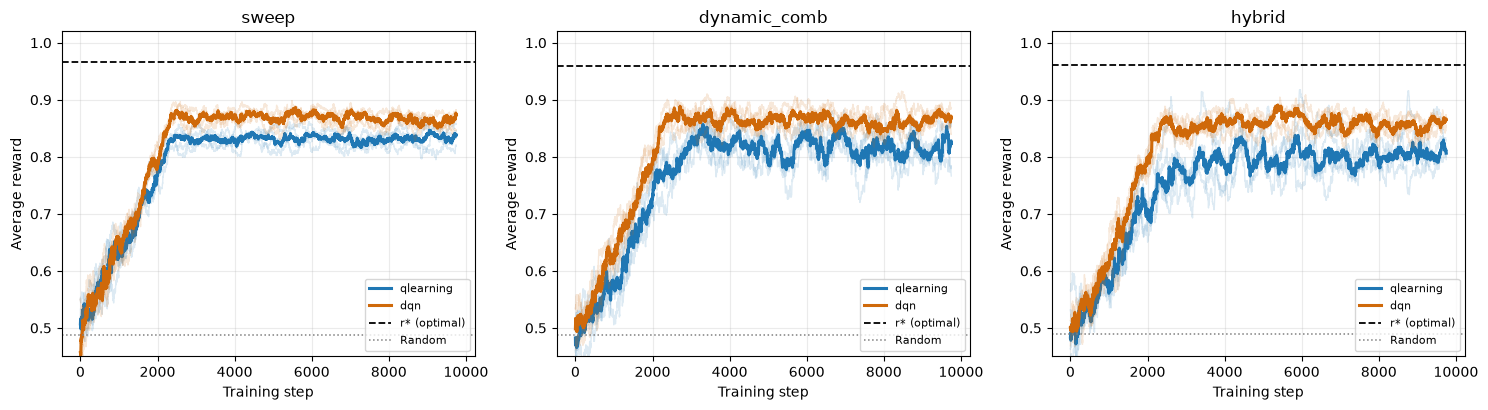

<Figure size 640x480 with 0 Axes>

In [5]:
SMOOTH = 250
STYLE = {"qlearning": "#1f77b4", "dqn": "#cf690a"}

random_ref = {}
for scenario in SCENARIOS:
    env = make_env(scenario, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
    random_ref[scenario] = np.median([
        evaluate_agent(make_agent("random", s, K=K), env, seed=s, n_steps=N_EVAL_STEPS)["r_bar"]
        for s in SEEDS_TRAIN
    ])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, scenario in zip(axes, SCENARIOS):
    for algo in LEARNING_ALGORITHMS:
        curves = [rolling_mean(training_logs[(scenario, algo, s)]["reward"], SMOOTH) for s in SEEDS_TRAIN]
        for c in curves:
            ax.plot(c, color=STYLE[algo], alpha=0.15, linewidth=1)
        ax.plot(np.median(np.stack(curves), axis=0), color=STYLE[algo], linewidth=2.2, label=algo)
    ax.axhline(r_star[scenario], color="black", linestyle="--", linewidth=1.3, label="r* (optimal)")
    ax.axhline(random_ref[scenario], color="gray", linestyle=":", linewidth=1.1, label="Random")
    ax.set_title(scenario, fontsize=12)
    ax.set_xlabel("Training step", fontsize=10)
    ax.set_ylabel("Average reward", fontsize=10)
    ax.set_ylim(0.45, 1.02)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
plt.savefig("plots/training_curves.png", dpi=300, bbox_inches="tight")

## Evaluation and Performance Summary

Evaluate learned policies and non-learning baselines over multiple seeds to tabulate the average reward $\bar{r}$, transmission rate $\bar{\mu}$, switching rate $\bar{\sigma}$, and optimality ratio $\eta$.

In [7]:
def full_metrics_table(scenario):
    env = make_env(scenario, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
    rows = []
    for method in ALL_METHODS:
        vals = []
        for seed in SEEDS_TRAIN:
            agent = make_agent(
                method,
                seed,
                K=K,
                T=T,
                gamma=cfg_agent["gamma"],
                ql_alpha=cfg_agent["qlearning"]["alpha"],
                ql_eps_start=cfg_agent["qlearning"]["eps_start"],
                ql_eps_end=cfg_agent["qlearning"]["eps_end"],
                ql_eps_decay=cfg_agent["qlearning"]["eps_decay"],
                dqn_lr=cfg_agent["dqn"]["lr"],
                dqn_eps_start=cfg_agent["dqn"]["eps_start"],
                dqn_eps_end=cfg_agent["dqn"]["eps_end"],
                dqn_eps_decay=cfg_agent["dqn"]["eps_decay"],
                dqn_replay=cfg_agent["dqn"]["replay_capacity"],
                dqn_warmup=cfg_agent["dqn"]["warmup_size"],
                dqn_batch=cfg_agent["dqn"]["batch_size"],
                dqn_target_sync=cfg_agent["dqn"]["target_sync_steps"],
                fc_hidden=cfg_agent["dqn"]["fc_hidden"],
                device=DEVICE,
            )
            if method in LEARNING_ALGORITHMS:
                agent.load(ckpt_path(method, scenario, seed, weights_dir=WEIGHTS_DIR))
            vals.append(evaluate_agent(agent, env, seed=seed, n_steps=N_EVAL_STEPS))
        r_bar = float(np.median([v["r_bar"] for v in vals]))
        mu_bar = float(np.median([v["mu_bar"] for v in vals]))
        sigma_bar = float(np.median([v["sigma_bar"] for v in vals]))
        avg_time = (
            np.mean([t for s in SEEDS_TRAIN if (t := training_time[(scenario, method, s)]) is not None])
            if method in LEARNING_ALGORITHMS
            else None
        )
        rows.append({
            "Method": method,
            "r_bar": round(r_bar, 4),
            "mu_bar": round(mu_bar, 4),
            "sigma_bar": round(sigma_bar, 4),
            "eta_%": round(100 * r_bar / r_star[scenario], 2),
            "train_time_s": round(avg_time, 1) if avg_time is not None else "--",
        })
    return pd.DataFrame(rows)

for scenario in SCENARIOS:
    print(f"Table - Scenario: {scenario}  (r* = {r_star[scenario]:.6f})")
    df_metrics = full_metrics_table(scenario)
    display(df_metrics)
    csv_path = f"results/metrics_{scenario}.csv"
    df_metrics.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

Table - Scenario: sweep  (r* = 0.966667)


,Method,r_bar,mu_bar,sigma_bar,eta_%,train_time_s
0,qlearning,0.8446,1.0000,0.7770,87.37,0.3
1,dqn,0.9112,1.0000,0.4440,94.26,42.9
2,fixed,0.6670,0.6670,0.0000,69.00,--
3,random,0.4869,0.6645,0.8895,50.37,--
4,reactive,0.6556,0.7130,0.2870,67.82,--


Saved: results/metrics_sweep.csv
Table - Scenario: dynamic_comb  (r* = 0.960000)


,Method,r_bar,mu_bar,sigma_bar,eta_%,train_time_s
0,qlearning,0.8515,0.9625,0.5250,88.70,0.3
1,dqn,0.9194,0.9655,0.2670,95.77,37.2
2,fixed,0.6450,0.6450,0.0000,67.19,--
3,random,0.4876,0.6655,0.8895,50.79,--
4,reactive,0.9502,0.9585,0.0415,98.98,--


Saved: results/metrics_dynamic_comb.csv
Table - Scenario: hybrid  (r* = 0.961561)


,Method,r_bar,mu_bar,sigma_bar,eta_%,train_time_s
0,qlearning,0.8219,0.9665,0.7160,85.48,0.9
1,dqn,0.9066,0.9805,0.3940,94.28,35.6
2,fixed,0.6585,0.6585,0.0000,68.48,--
3,random,0.4896,0.6665,0.8895,50.92,--
4,reactive,0.8093,0.8410,0.1585,84.17,--


Saved: results/metrics_hybrid.csv


## Cross-Domain Generalization

Evaluate policies trained under one jammer scenario against environments driven by other jamming strategies.

[  17.9s] transfer matrix done for qlearning
[ 546.8s] transfer matrix done for dqn


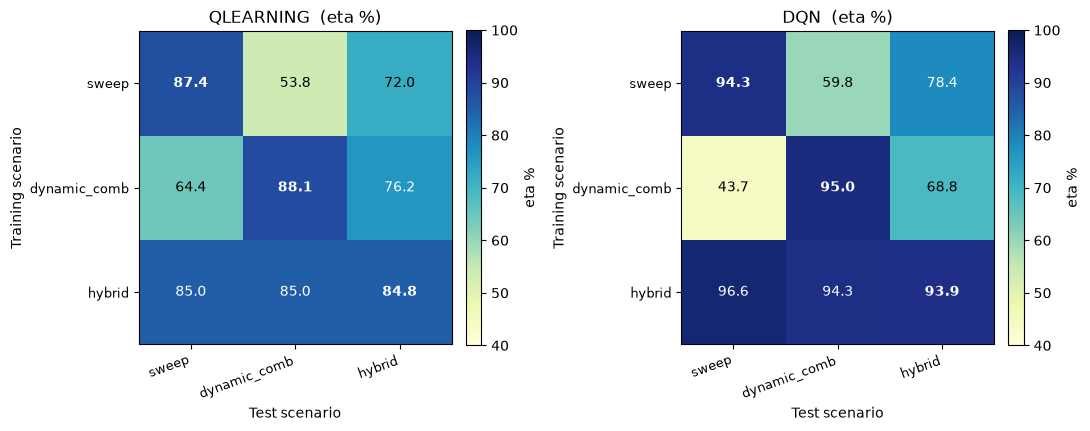

<Figure size 640x480 with 0 Axes>

In [8]:
cross_domain_raw = {}
t0 = time.time()
for algo in LEARNING_ALGORITHMS:
    for train_s in SCENARIOS:
        for test_s in SCENARIOS:
            n_steps = N_EVAL_STEPS if train_s == test_s else N_EVAL_STEPS_CROSSDOMAIN
            test_env = make_env(test_s, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
            per_policy = []
            for seed in SEEDS_TRAIN:
                agent = make_agent(
                    algo,
                    seed,
                    K=K,
                    T=T,
                    gamma=cfg_agent["gamma"],
                    ql_alpha=cfg_agent["qlearning"]["alpha"],
                    ql_eps_start=cfg_agent["qlearning"]["eps_start"],
                    ql_eps_end=cfg_agent["qlearning"]["eps_end"],
                    ql_eps_decay=cfg_agent["qlearning"]["eps_decay"],
                    dqn_lr=cfg_agent["dqn"]["lr"],
                    dqn_eps_start=cfg_agent["dqn"]["eps_start"],
                    dqn_eps_end=cfg_agent["dqn"]["eps_end"],
                    dqn_eps_decay=cfg_agent["dqn"]["eps_decay"],
                    dqn_replay=cfg_agent["dqn"]["replay_capacity"],
                    dqn_warmup=cfg_agent["dqn"]["warmup_size"],
                    dqn_batch=cfg_agent["dqn"]["batch_size"],
                    dqn_target_sync=cfg_agent["dqn"]["target_sync_steps"],
                    fc_hidden=cfg_agent["dqn"]["fc_hidden"],
                    device=DEVICE,
                )
                agent.load(ckpt_path(algo, train_s, seed, weights_dir=WEIGHTS_DIR))
                per_policy.append(evaluate_agent_multi_seed(agent, test_env, SEEDS_TEST, n_steps))
            cross_domain_raw[(algo, train_s, test_s)] = float(np.median(per_policy))
    print(f"[{time.time()-t0:6.1f}s] transfer matrix done for {algo}")

def build_eta_matrix(algo):
    mat = np.zeros((len(SCENARIOS), len(SCENARIOS)))
    for i, train_s in enumerate(SCENARIOS):
        for j, test_s in enumerate(SCENARIOS):
            mat[i, j] = 100 * cross_domain_raw[(algo, train_s, test_s)] / r_star[test_s]
    return mat

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, algo in zip(axes, LEARNING_ALGORITHMS):
    mat = build_eta_matrix(algo)
    im = ax.imshow(mat, cmap="YlGnBu", vmin=40, vmax=100)
    ax.set_xticks(range(len(SCENARIOS)))
    ax.set_xticklabels(SCENARIOS, rotation=20, ha="right", fontsize=9)
    ax.set_yticks(range(len(SCENARIOS)))
    ax.set_yticklabels(SCENARIOS, fontsize=9)
    ax.set_xlabel("Test scenario", fontsize=10)
    ax.set_ylabel("Training scenario", fontsize=10)
    ax.set_title(f"{algo.upper()}  (eta %)", fontsize=12)
    for i in range(len(SCENARIOS)):
        for j in range(len(SCENARIOS)):
            color = "white" if mat[i, j] > 75 else "black"
            ax.text(
                j,
                i,
                f"{mat[i,j]:.1f}",
                ha="center",
                va="center",
                color=color,
                fontweight="bold" if i == j else "normal",
                fontsize=10,
            )
    fig.colorbar(im, ax=ax, label="eta %", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
plt.savefig("plots/heatmaps.png", dpi=300, bbox_inches="tight")

## Waterfall Snapshots

Visualize rolling allocations and collision outcomes against jammed frequency slots on both training and held-out test seeds.

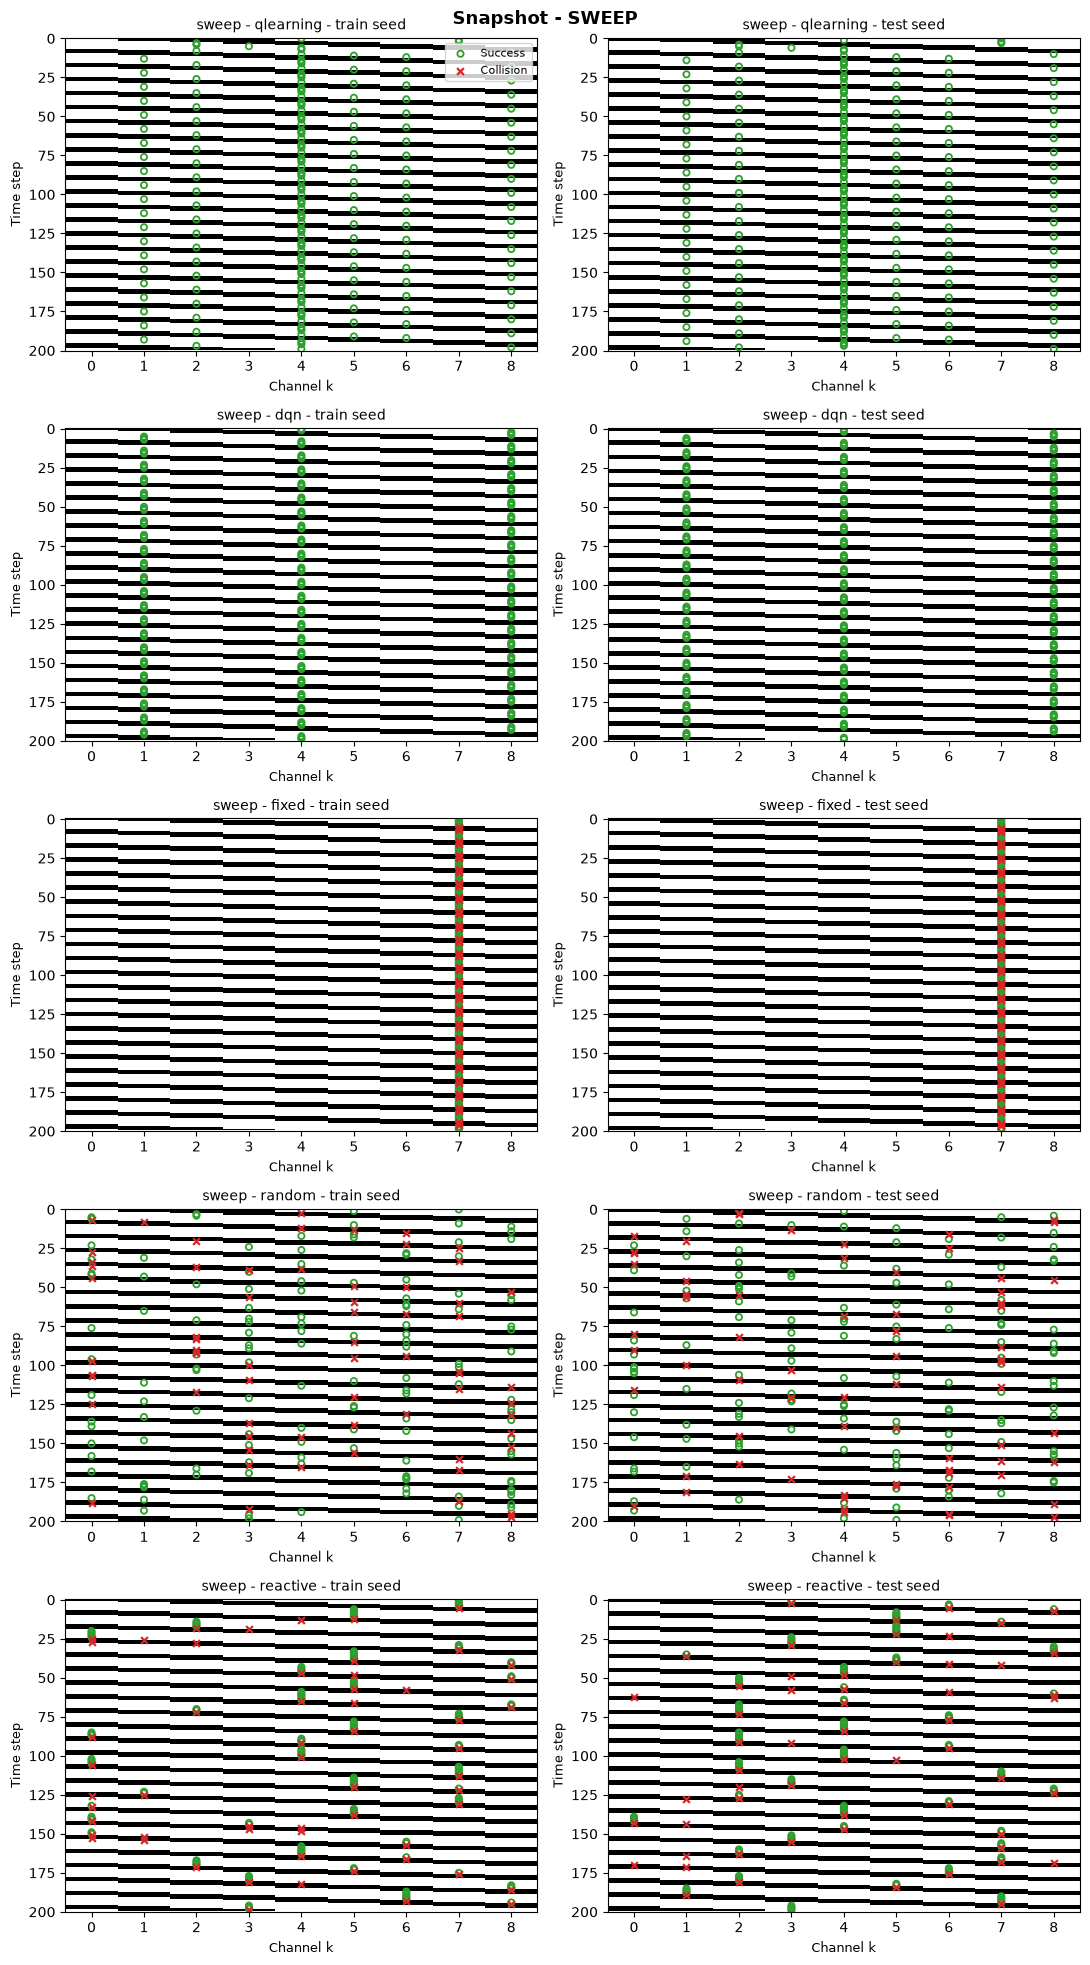

<Figure size 640x480 with 0 Axes>

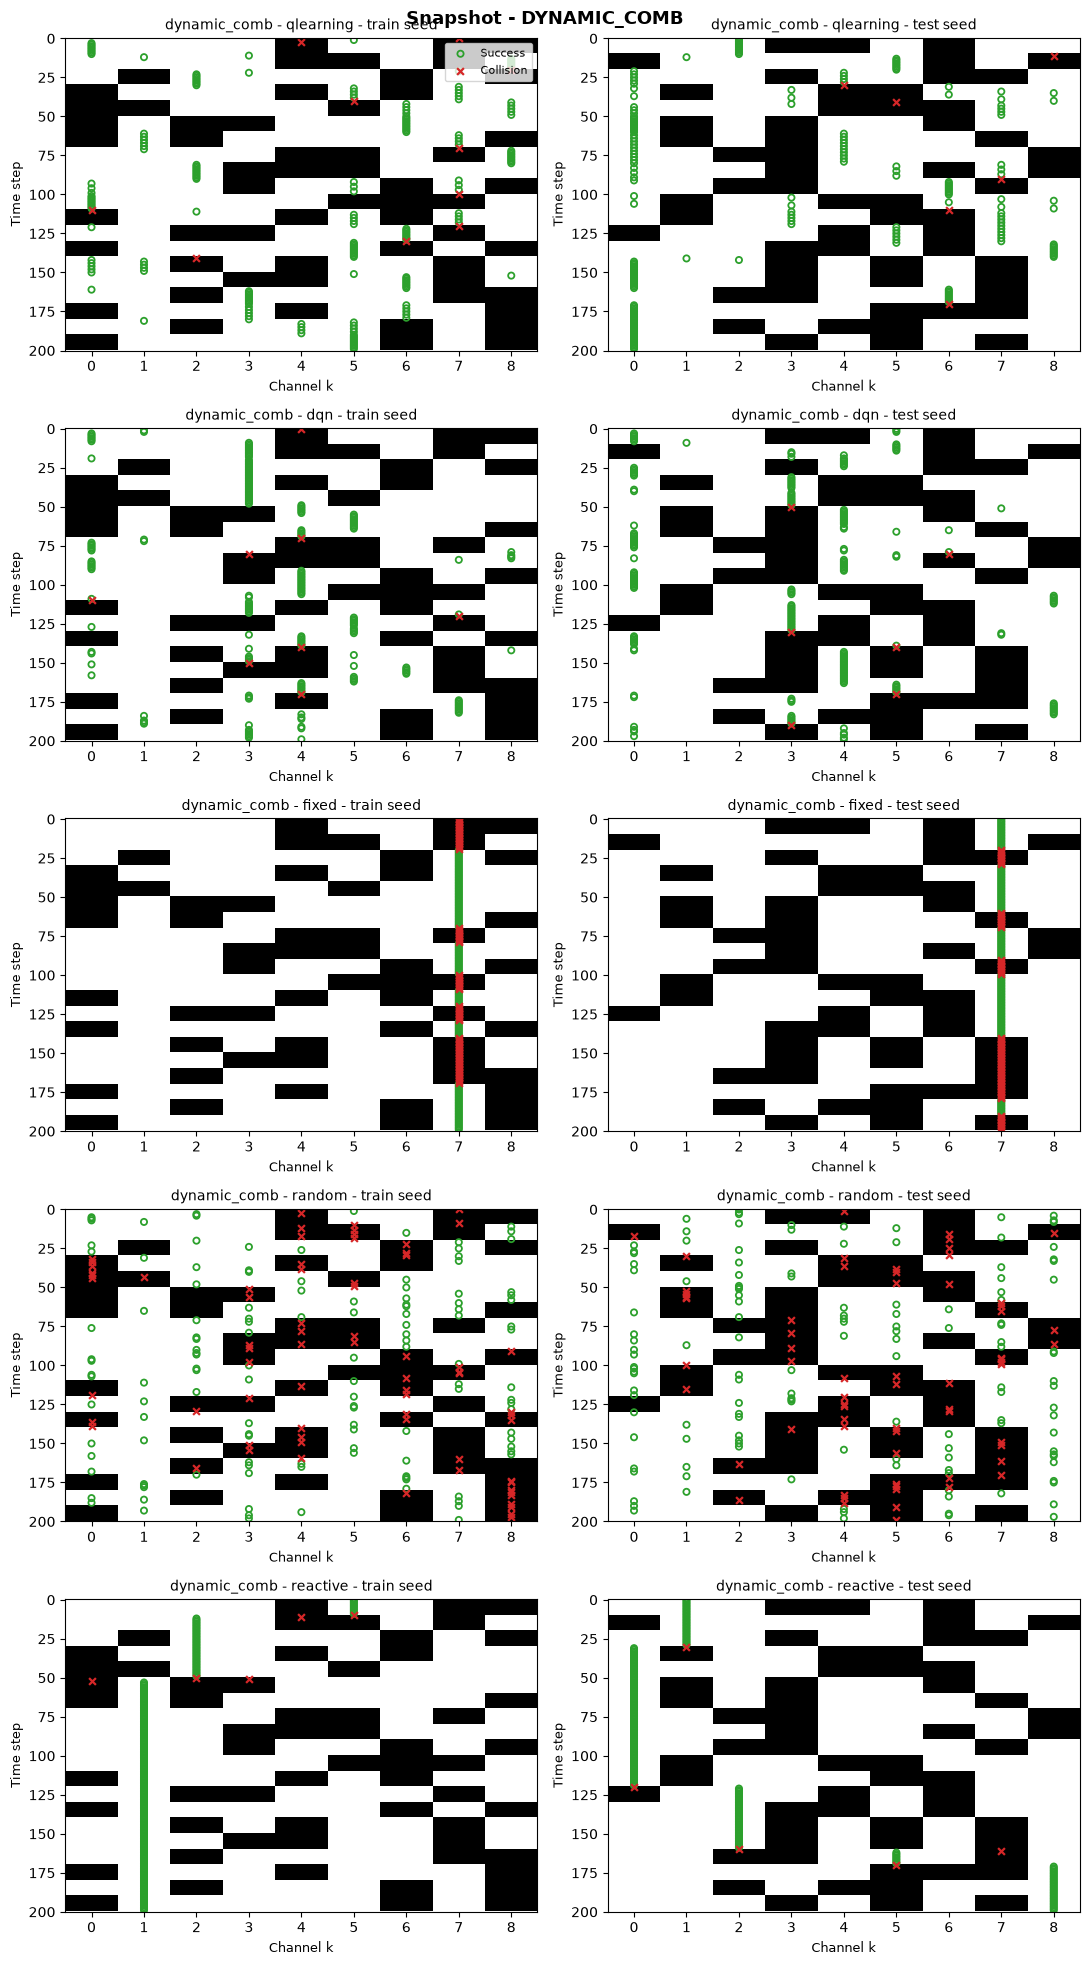

<Figure size 640x480 with 0 Axes>

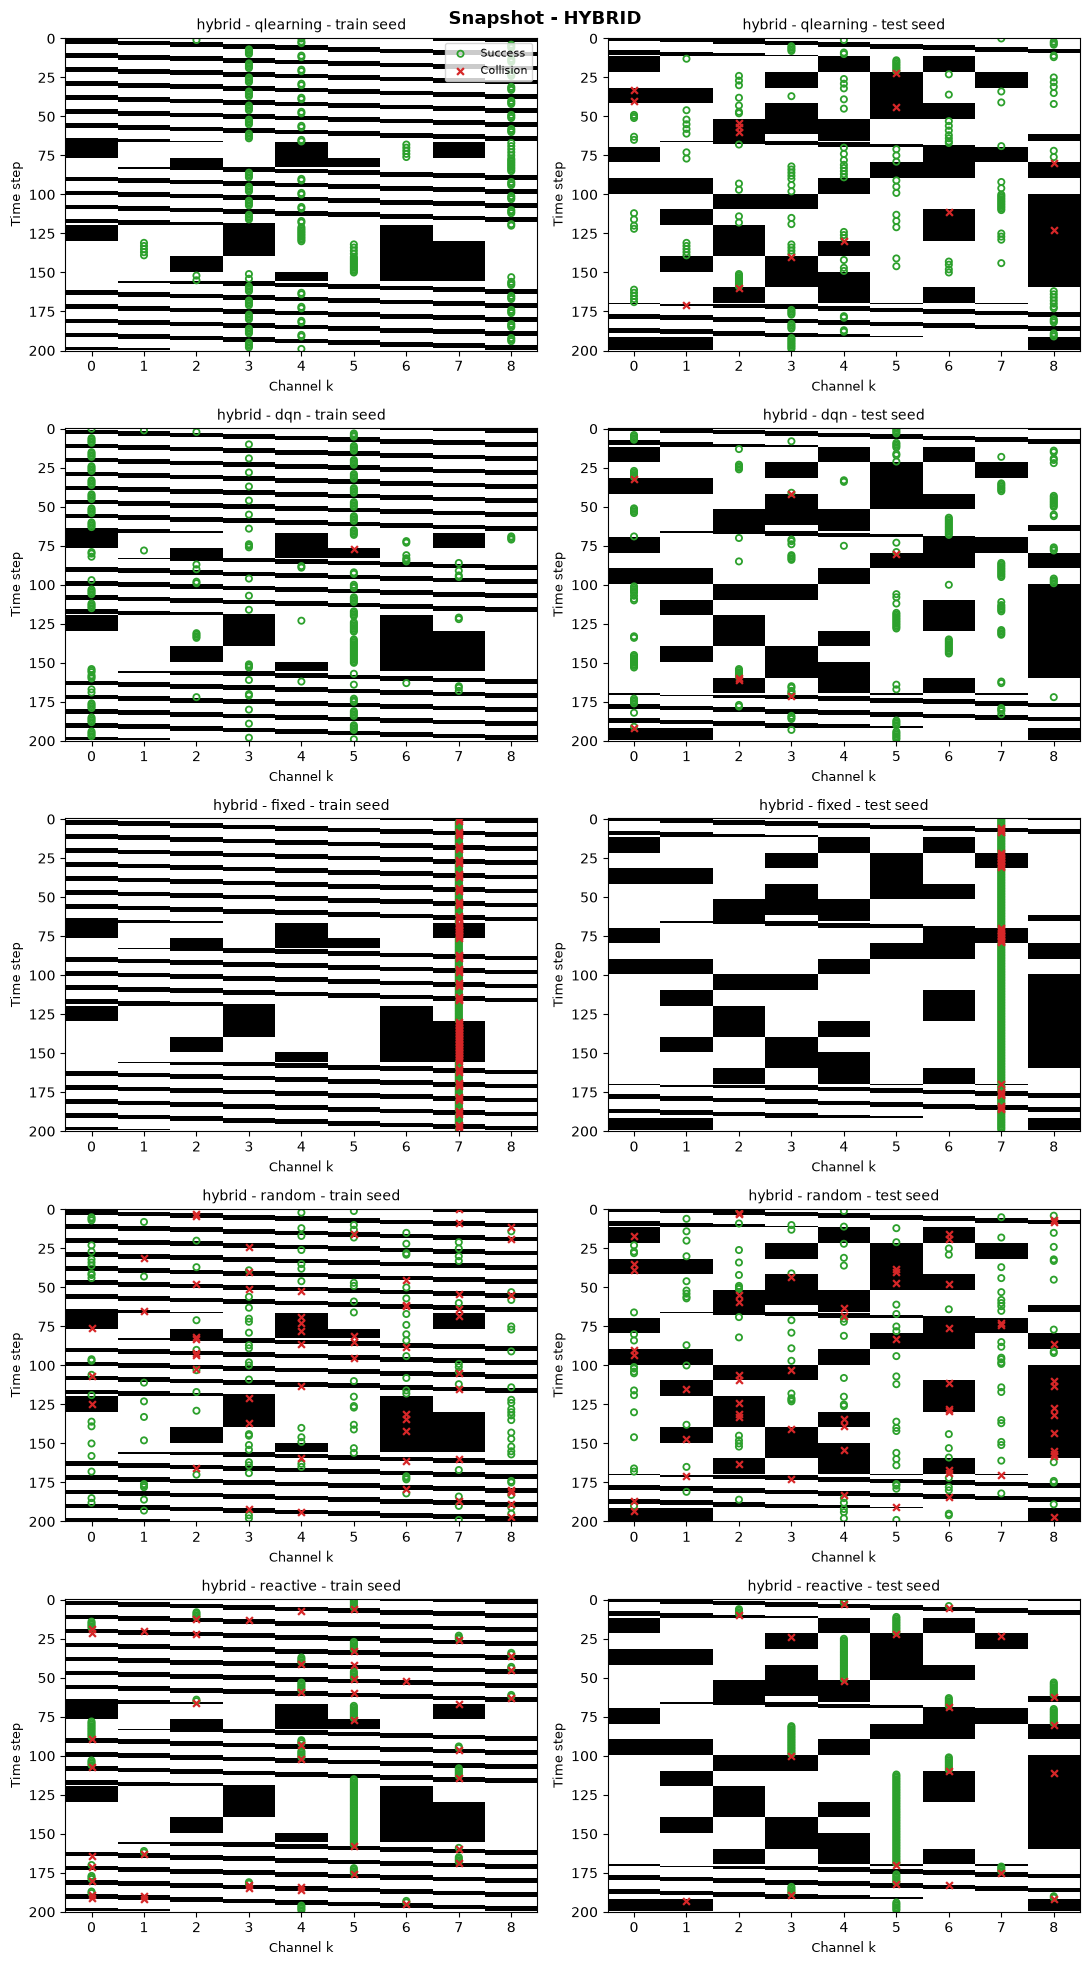

<Figure size 640x480 with 0 Axes>

In [9]:
SNAPSHOT_SEED_TRAIN = 0
SNAPSHOT_SEED_TEST = SEEDS_TEST[0]
SNAPSHOT_WINDOW = 200

for scenario in SCENARIOS:
    fig, axes = plt.subplots(len(ALL_METHODS), 2, figsize=(11, 4.0 * len(ALL_METHODS)))
    for row, method in enumerate(ALL_METHODS):
        agent = make_agent(
            method,
            SNAPSHOT_SEED_TRAIN,
            K=K,
            T=T,
            gamma=cfg_agent["gamma"],
            ql_alpha=cfg_agent["qlearning"]["alpha"],
            ql_eps_start=cfg_agent["qlearning"]["eps_start"],
            ql_eps_end=cfg_agent["qlearning"]["eps_end"],
            ql_eps_decay=cfg_agent["qlearning"]["eps_decay"],
            dqn_lr=cfg_agent["dqn"]["lr"],
            dqn_eps_start=cfg_agent["dqn"]["eps_start"],
            dqn_eps_end=cfg_agent["dqn"]["eps_end"],
            dqn_eps_decay=cfg_agent["dqn"]["eps_decay"],
            dqn_replay=cfg_agent["dqn"]["replay_capacity"],
            dqn_warmup=cfg_agent["dqn"]["warmup_size"],
            dqn_batch=cfg_agent["dqn"]["batch_size"],
            dqn_target_sync=cfg_agent["dqn"]["target_sync_steps"],
            fc_hidden=cfg_agent["dqn"]["fc_hidden"],
            device=DEVICE,
        )
        if method in LEARNING_ALGORITHMS:
            agent.load(ckpt_path(method, scenario, SNAPSHOT_SEED_TRAIN, weights_dir=WEIGHTS_DIR))

        env_train = make_env(scenario, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
        occ, act, out = rollout_waterfall(agent, env_train, SNAPSHOT_SEED_TRAIN, SNAPSHOT_WINDOW)
        plot_waterfall(axes[row, 0], occ, act, out, f"{scenario} - {method} - train seed", K=K)

        env_test = make_env(scenario, K=K, T=T, M=M, dwell=DWELL, rho_hybrid=RHO_HYBRID, lambda_switch=LAMBDA, burn_in_steps=BURN_IN)
        occ, act, out = rollout_waterfall(agent, env_test, SNAPSHOT_SEED_TEST, SNAPSHOT_WINDOW)
        plot_waterfall(axes[row, 1], occ, act, out, f"{scenario} - {method} - test seed", K=K)

    axes[0, 0].legend(loc="upper right", fontsize=8)
    plt.suptitle(f"Snapshot - {scenario.upper()}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"plots/snapshot_{scenario}.png", dpi=300, bbox_inches="tight")